# 03 - Regression Models for Popularity

Goal: predict a song's `popularity` score from Spotify audio characteristics. This notebook compares multiple linear regression and degree-2 polynomial regression using train/test MSE.

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw" / "dataset.csv"
DATA_CLEAN = PROJECT_ROOT / "data" / "processed" / "spotify_tracks_clean.csv"

RANDOM_STATE = 42

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", palette="Set2")
df = pd.read_csv(DATA_CLEAN)
print(df.shape)
display(df.head())

(89741, 23)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min,is_explicit,popularity_class
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.844433,0,High
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.493500,0,High
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.513767,0,High
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.365550,0,High
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.314217,0,High


## Feature Selection

Identifiers and text metadata are excluded because they do not represent transferable audio characteristics. Genre is included as a one-hot encoded business context feature. For polynomial regression, only numeric audio features are expanded; genre remains linear so the model captures nonlinear audio effects without creating thousands of genre interaction columns.

In [3]:
target = "popularity"
numeric_features = [
    "duration_min", "is_explicit", "danceability", "energy", "key", "loudness",
    "mode", "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "time_signature"
]
categorical_features = ["track_genre"]

X = df[numeric_features + categorical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)

(71792, 15) (17949, 15)


In [4]:
try:
    encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)

linear_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("genre", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", encoder)
        ]), categorical_features)
    ]
)

linear_model = Pipeline([
    ("preprocess", linear_preprocess),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_train_pred = linear_model.predict(X_train)
linear_test_pred = linear_model.predict(X_test)

linear_train_mse = mean_squared_error(y_train, linear_train_pred)
linear_test_mse = mean_squared_error(y_test, linear_test_pred)
print(f"Linear train MSE: {linear_train_mse:.3f}")
print(f"Linear test MSE: {linear_test_mse:.3f}")

Linear train MSE: 283.706
Linear test MSE: 283.750


## Polynomial Regression

The polynomial model is tuned over degrees 2 and 3 with Ridge regularization. Degree 2 captures curved relationships and pairwise interactions, while degree 3 allows a slightly richer nonlinear shape. Ridge regularization is used to reduce overfitting risk from the expanded feature space.

In [5]:
def make_encoder(drop_first=True):
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            drop="first" if drop_first else None,
            sparse_output=False,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            drop="first" if drop_first else None,
            sparse=False,
        )


polynomial_results = []
polynomial_models = {}

for degree in [2, 3]:
    for alpha in [0.1, 1.0, 10.0, 100.0]:
        polynomial_preprocess = ColumnTransformer(
            transformers=[
                ("num_poly", Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                    ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
                ]), numeric_features),
                ("genre", Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", make_encoder(drop_first=True)),
                ]), categorical_features),
            ]
        )

        model_name = f"Polynomial Ridge degree {degree}, alpha {alpha:g}"
        candidate = Pipeline([
            ("preprocess", polynomial_preprocess),
            ("model", Ridge(alpha=alpha)),
        ])
        candidate.fit(X_train, y_train)
        train_pred = candidate.predict(X_train)
        test_pred = candidate.predict(X_test)
        train_mse = mean_squared_error(y_train, train_pred)
        test_mse = mean_squared_error(y_test, test_pred)
        polynomial_results.append({
            "model": model_name,
            "degree": degree,
            "alpha": alpha,
            "train_mse": train_mse,
            "test_mse": test_mse,
            "test_rmse_popularity_points": np.sqrt(test_mse),
            "generalization_gap": test_mse - train_mse,
        })
        polynomial_models[model_name] = candidate

polynomial_results_df = (
    pd.DataFrame(polynomial_results)
    .sort_values("test_mse")
    .reset_index(drop=True)
)
display(polynomial_results_df.round(3))

best_polynomial_row = polynomial_results_df.iloc[0]
best_polynomial_model = polynomial_models[best_polynomial_row["model"]]
poly_train_pred = best_polynomial_model.predict(X_train)
poly_test_pred = best_polynomial_model.predict(X_test)
poly_train_mse = best_polynomial_row["train_mse"]
poly_test_mse = best_polynomial_row["test_mse"]
print(f"Best polynomial model: {best_polynomial_row['model']}")
print(f"Polynomial train MSE: {poly_train_mse:.3f}")
print(f"Polynomial test MSE: {poly_test_mse:.3f}")

,model,degree,alpha,train_mse,test_mse,test_rmse_popularity_points,generalization_gap
0,"Polynomial Ridge degree 3, alpha 0.1",3,0.1,275.662,281.250,16.771,5.588
1,"Polynomial Ridge degree 3, alpha 1",3,1.0,275.674,281.305,16.772,5.631
2,"Polynomial Ridge degree 3, alpha 10",3,10.0,275.957,281.738,16.785,5.781
3,"Polynomial Ridge degree 2, alpha 0.1",2,0.1,280.421,281.760,16.786,1.338
4,"Polynomial Ridge degree 2, alpha 1",2,1.0,280.433,281.814,16.787,1.381
5,"Polynomial Ridge degree 2, alpha 10",2,10.0,280.709,282.225,16.800,1.516
6,"Polynomial Ridge degree 3, alpha 100",3,100.0,278.936,284.603,16.870,5.667
7,"Polynomial Ridge degree 2, alpha 100",2,100.0,283.657,284.888,16.879,1.231


Best polynomial model: Polynomial Ridge degree 3, alpha 0.1
Polynomial train MSE: 275.662
Polynomial test MSE: 281.250


## Tuned Histogram Gradient Boosting Regression

Linear and polynomial regression are useful for interpretation, but gradient boosting can model nonlinear thresholds and interactions without manually expanding every feature. This tuning pass compares learning rates while keeping early stopping enabled to control overfitting.

In [6]:
boosting_results = []
boosting_models = {}

for learning_rate in [0.04, 0.06, 0.08]:
    boosting_preprocess = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_features),
            ("genre", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_encoder(drop_first=False)),
            ]), categorical_features),
        ]
    )
    model_name = f"HistGradientBoosting lr {learning_rate}"
    candidate = Pipeline([
        ("preprocess", boosting_preprocess),
        ("model", HistGradientBoostingRegressor(
            max_iter=250,
            learning_rate=learning_rate,
            max_leaf_nodes=31,
            l2_regularization=0.1,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=RANDOM_STATE,
        )),
    ])
    candidate.fit(X_train, y_train)
    train_pred = candidate.predict(X_train)
    test_pred = candidate.predict(X_test)
    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    boosting_results.append({
        "model": model_name,
        "learning_rate": learning_rate,
        "train_mse": train_mse,
        "test_mse": test_mse,
        "test_rmse_popularity_points": np.sqrt(test_mse),
        "generalization_gap": test_mse - train_mse,
    })
    boosting_models[model_name] = candidate

boosting_results_df = (
    pd.DataFrame(boosting_results)
    .sort_values("test_mse")
    .reset_index(drop=True)
)
display(boosting_results_df.round(3))

best_boosting_row = boosting_results_df.iloc[0]
best_boosting_model = boosting_models[best_boosting_row["model"]]
boosting_train_pred = best_boosting_model.predict(X_train)
boosting_test_pred = best_boosting_model.predict(X_test)
boosting_train_mse = best_boosting_row["train_mse"]
boosting_test_mse = best_boosting_row["test_mse"]
print(f"Best boosted model: {best_boosting_row['model']}")
print(f"Boosting train MSE: {boosting_train_mse:.3f}")
print(f"Boosting test MSE: {boosting_test_mse:.3f}")

,model,learning_rate,train_mse,test_mse,test_rmse_popularity_points,generalization_gap
0,HistGradientBoosting lr 0.08,0.08,226.335,251.406,15.856,25.071
1,HistGradientBoosting lr 0.06,0.06,234.778,254.810,15.963,20.032
2,HistGradientBoosting lr 0.04,0.04,246.477,260.114,16.128,13.638


Best boosted model: HistGradientBoosting lr 0.08
Boosting train MSE: 226.335
Boosting test MSE: 251.406


In [7]:
mse_table = pd.DataFrame([
    {
        "model": "Multiple Linear Regression baseline",
        "train_mse": linear_train_mse,
        "test_mse": linear_test_mse,
        "test_rmse_popularity_points": np.sqrt(linear_test_mse),
        "generalization_gap": linear_test_mse - linear_train_mse,
    },
    best_polynomial_row[["model", "train_mse", "test_mse", "test_rmse_popularity_points", "generalization_gap"]].to_dict(),
    best_boosting_row[["model", "train_mse", "test_mse", "test_rmse_popularity_points", "generalization_gap"]].to_dict(),
])
mse_table["test_mse_improvement_vs_baseline"] = linear_test_mse - mse_table["test_mse"]
mse_table["test_mse_improvement_percent"] = 100 * mse_table["test_mse_improvement_vs_baseline"] / linear_test_mse
mse_table = mse_table.sort_values("test_mse").reset_index(drop=True)
display(mse_table.round(3))

,model,train_mse,test_mse,test_rmse_popularity_points,generalization_gap,test_mse_improvement_vs_baseline,test_mse_improvement_percent
0,HistGradientBoosting lr 0.08,226.335,251.406,15.856,25.071,32.344,11.399
1,"Polynomial Ridge degree 3, alpha 0.1",275.662,281.250,16.771,5.588,2.500,0.881
2,Multiple Linear Regression baseline,283.706,283.750,16.845,0.044,0.000,0.000


## Which Features Have the Strongest Effect?

Linear coefficients are interpreted after scaling numeric features. Larger absolute coefficients indicate stronger association with popularity in the fitted linear model, holding other included variables constant.

In [8]:
preprocessor = linear_model.named_steps["preprocess"]
feature_names = preprocessor.get_feature_names_out()
coefficients = linear_model.named_steps["model"].coef_

coef_table = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
    .assign(abs_coefficient=lambda x: x["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)
display(coef_table.head(20))

,feature,coefficient,abs_coefficient
72,genre__track_genre_iranian,-38.737928,38.737928
106,genre__track_genre_romance,-37.450894,37.450894
80,genre__track_genre_latin,-32.461991,32.461991
77,genre__track_genre_jazz,-31.473212,31.473212
37,genre__track_genre_detroit-techno,-31.189584,31.189584
26,genre__track_genre_chicago-house,-30.217325,30.217325
79,genre__track_genre_kids,-27.233711,27.233711
29,genre__track_genre_classical,-26.706648,26.706648
55,genre__track_genre_grindcore,-26.222319,26.222319
67,genre__track_genre_idm,-25.859308,25.859308


## Actual vs. Predicted Values

Points near the diagonal line are accurate predictions. Spread around the line represents prediction error in popularity points.

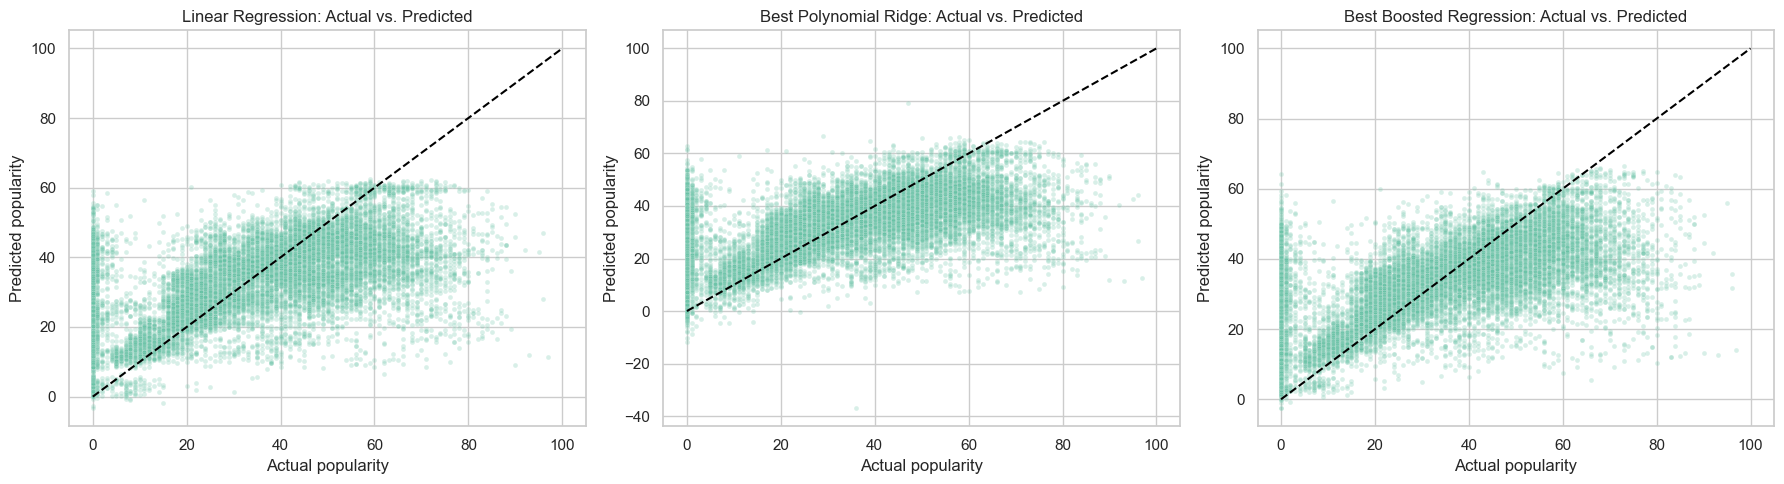

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=y_test, y=linear_test_pred, alpha=0.25, s=12, ax=axes[0])
axes[0].plot([0, 100], [0, 100], color="black", linestyle="--")
axes[0].set_title("Linear Regression: Actual vs. Predicted")
axes[0].set_xlabel("Actual popularity")
axes[0].set_ylabel("Predicted popularity")

sns.scatterplot(x=y_test, y=poly_test_pred, alpha=0.25, s=12, ax=axes[1])
axes[1].plot([0, 100], [0, 100], color="black", linestyle="--")
axes[1].set_title("Best Polynomial Ridge: Actual vs. Predicted")
axes[1].set_xlabel("Actual popularity")
axes[1].set_ylabel("Predicted popularity")

sns.scatterplot(x=y_test, y=boosting_test_pred, alpha=0.25, s=12, ax=axes[2])
axes[2].plot([0, 100], [0, 100], color="black", linestyle="--")
axes[2].set_title("Best Boosted Regression: Actual vs. Predicted")
axes[2].set_xlabel("Actual popularity")
axes[2].set_ylabel("Predicted popularity")

plt.tight_layout()
plt.show()

In [10]:
best_model = mse_table.sort_values("test_mse").iloc[0]
overfit_notes = []
for _, row in mse_table.iterrows():
    if row["generalization_gap"] > 25:
        overfit_notes.append(f"{row['model']} shows a notable train/test gap.")
    else:
        overfit_notes.append(f"{row['model']} has a modest train/test gap.")

print("Interpretation:")
baseline_mse = mse_table.loc[mse_table["model"] == "Multiple Linear Regression baseline", "test_mse"].iloc[0]
improvement = baseline_mse - best_model["test_mse"]
improvement_percent = 100 * improvement / baseline_mse

print(f"- Best test MSE model: {best_model['model']} with MSE {best_model['test_mse']:.2f}.")
print(f"- The RMSE is about {best_model['test_rmse_popularity_points']:.2f} popularity points.")
print(f"- Compared with the original linear baseline, test MSE improved by {improvement:.2f} points ({improvement_percent:.2f}%).")
print("- In business terms, this error means the model is better for estimating broad popularity potential than for guaranteeing an exact Spotify popularity score.")
for note in overfit_notes:
    print("-", note)
print("- Audio features influence popularity, but large residual spread suggests artist, playlist, market, recency, and promotion effects are also important.")

Interpretation:
- Best test MSE model: HistGradientBoosting lr 0.08 with MSE 251.41.
- The RMSE is about 15.86 popularity points.
- Compared with the original linear baseline, test MSE improved by 32.34 points (11.40%).
- In business terms, this error means the model is better for estimating broad popularity potential than for guaranteeing an exact Spotify popularity score.
- HistGradientBoosting lr 0.08 shows a notable train/test gap.
- Polynomial Ridge degree 3, alpha 0.1 has a modest train/test gap.
- Multiple Linear Regression baseline has a modest train/test gap.
- Audio features influence popularity, but large residual spread suggests artist, playlist, market, recency, and promotion effects are also important.


## Executive Conclusion

The regression models provide a baseline for estimating expected popularity from audio characteristics. If the polynomial model has lower test MSE without a large generalization gap, nonlinear effects are useful. If the linear model is competitive, Spotify should prefer it for interpretability. In either case, predicted popularity should support discovery and catalog prioritization rather than replace business judgment.